In [ ]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
import random
from typing import Literal
from dotenv import load_dotenv


**LEESON 2 - SIMPLE GRAPH**

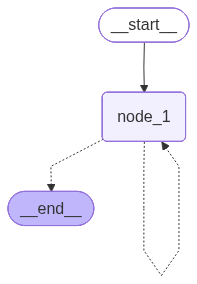

---Node 1---


{'graph_state': 'Hi, this is Lance. I am'}

In [4]:

class State(TypedDict):
    graph_state: str

def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def decide_mood(state) -> Literal["node_1", END]:

    user_input = state['graph_state'] 

    if random.random() < 0.5:

        return END

    return "node_1"

# Build Graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

# Execute
graph.invoke({"graph_state" : "Hi, this is Lance."})

**LESSON 4 - CHAIN**

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [4]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

load_dotenv() # Charge le fichier .env
groq_key = os.getenv("GROQ_APP_KEY")
GROQ_MODEL = "llama-3.1-8b-instant"

llm = ChatGroq(model="llama-3.1-8b-instant", api_key=groq_key)
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [13]:
print("=== CONTENU ===")
print(result.content)
print(result.type)

print("\n=== TOKENS ===")
print(result.usage_metadata)

print("\n=== METADATA ===")
print(result.response_metadata)

print("\n=== TOOLS ===")
print(result.tool_calls)
print(result.invalid_tool_calls)

print("\n=== AFFICHAGE ===")
result.pretty_print()

print("\n=== DUMP ===")
print(result.model_dump())
print(result.model_dump_json())

=== CONTENU ===
The orca, also known as the killer whale, is a popular species among marine wildlife enthusiasts. One of the best places to see orcas in the US is in the Pacific Northwest, specifically in the waters of Washington state.

The San Juan Islands, located off the coast of Washington state, are known for their orca sightings. The islands are home to a resident population of orcas, which can be seen on guided tours or by visiting the island's many parks and wildlife refuges.

Some popular spots for orca sightings in the San Juan Islands include:

1. Puget Sound: Orcas can be seen in the sound, particularly in the areas around the San Juan Islands and the Olympic Peninsula.
2. San Juan Islands National Monument: This national monument protects a large area of marine habitat, including orca feeding grounds.
3. Lime Kiln Point State Park: Located on San Juan Island, this park is known for its excellent orca viewing opportunities.
4. Whale Watch Tours: There are many guided tours

In [ ]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b


"""
Le LLM n'appel pas mais renvoie l'appel a faire avec les arguments
Permet au LLM de décider si il faut appeler extract_city ou extract_company
Permet un graph dynamique aulieu d'un graph linéaire
"""
llm_with_tools = llm.bind_tools([multiply])

In [15]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [16]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': '9htzecxp7',
  'type': 'tool_call'}]

In [ ]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [19]:
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages
class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='52579af5-8f77-4f2f-b28e-fff519e7ab3a', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='762a7a02-1824-40af-ae40-7c695b22bf86'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='38504cc7-644e-4a0e-a49a-3e7f8caa4f2c', tool_calls=[], invalid_tool_calls=[])]

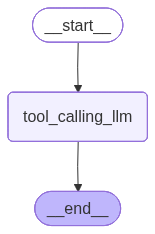

In [20]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Nice to meet you. Is there something I can help you with?


In [22]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (wr1q2matc)
 Call ID: wr1q2matc
  Args:
    a: 2
    b: 3


**LESSON 5 - ROUTER**

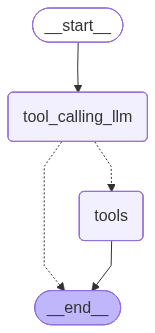

In [24]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello?
================================== Ai Message ==================================

I'm here to help. What would you like to do?


In [30]:
%%writefile extract_city_company_route_example.py

@tool
def extract_company(job_title: str, job_description: str) -> str:
    """Extrait le nom de l'entreprise depuis le titre et la description de l'offre."""
    response = llm.invoke([HumanMessage(content=f"""
Extrais uniquement le nom de l'entreprise.
Titre : {job_title}
Description : {job_description}
""")])
    return response.content.strip()

@tool  
def extract_city(location_raw: str, job_title: str, job_description: str) -> str:
    """Extrait la ville depuis un texte de localisation brut."""
    response = llm.invoke([HumanMessage(content=f"""
Location : {location_raw}
Titre : {job_title}
Description : {job_description}
""")])
    return response.content.strip()

def update_state(state: JobOfferState) -> JobOfferState:
    """Lit les résultats des tools et met à jour le state."""
    updates = {}
    
    for message in state["messages"]:
        if isinstance(message, ToolMessage):
            if message.name == "extract_company":
                updates["company"] = message.content
            elif message.name == "extract_city":
                updates["city"] = message.content
    
    return updates

def tool_calling_llm(state: JobOfferState) -> dict:
    system = SystemMessage(content="""
    Tu es un assistant d'extraction de données d'offres d'emploi.

    - Si company est null ou vide → appelle extract_company
    - Si location_raw est null ou vide et que city est vide ou null également → appelle extract_city  
    - Sinon → ne fais rien et termine
    """)
    
    user = HumanMessage(content=f"""
company: {state.get('company')}
city: {state.get('city')}
location_raw: {state.get('location_raw')}
job_title: {state.get('job_title')}
job_description: {state.get('job_description')}
""")
    
    return {"messages": [llm_with_tools.invoke([system, user])]}


Writing extract_city_company_route_example.py


# Parallelisation

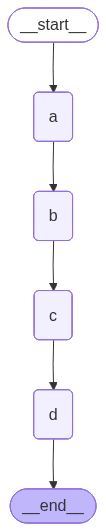

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A", "I'm B"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]
Temps d'exécution : 0.001000s


In [10]:
from IPython.display import Image, display

from typing import Any, List
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

import operator
from typing import Annotated

class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    state: Annotated[list, operator.add]
class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
import time

start = time.time()

graph.invoke({"state": []})

end = time.time()
print(f"Temps d'exécution : {end - start:.6f}s")

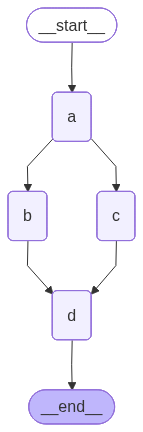

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]
Temps d'exécution : 0.001000s


In [11]:
import operator
from typing import Annotated

class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    state: Annotated[list, operator.add]

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
import time

start = time.time()

graph.invoke({"state": []})

end = time.time()
print(f"Temps d'exécution : {end - start:.6f}s")

# WEB SEARCH

In [12]:
from dotenv import load_dotenv
import os

load_dotenv() # Charge le fichier .env
groq_key = os.getenv("GROQ_APP_KEY")
GROQ_MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

llm = ChatGroq(
    temperature=0, 
    model_name=GROQ_MODEL, 
    groq_api_key=groq_key
)



In [13]:
class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]

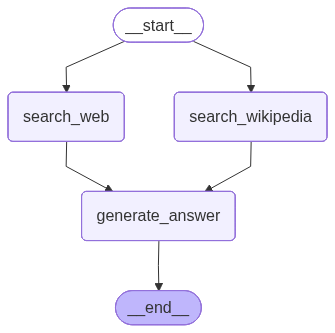

KeyError: 'question'

In [17]:
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_community.document_loaders import WikipediaLoader
from langchain_tavily import TavilySearch  # updated since filming

def search_web(state):
    
    """ Retrieve docs from web search """

    # Search
    tavily_search = TavilySearch(max_results=3)
    data = tavily_search.invoke({"query": state['question']})
    search_docs = data.get("results", data)

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def search_wikipedia(state):
    
    """ Retrieve docs from wikipedia """

    # Search
    search_docs = WikipediaLoader(query=state['question'], 
                                  load_max_docs=2).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def generate_answer(state):
    
    """ Node to answer a question """

    # Get state
    context = state["context"]
    question = state["question"]

    # Template
    answer_template = """Answer the question {question} using this context: {context}"""
    answer_instructions = answer_template.format(question=question, 
                                                       context=context)    
    
    # Answer
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content=f"Answer the question.")])
      
    # Append it to state
    return {"answer": answer}

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("search_web",search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# Flow
builder.add_edge(START, "search_wikipedia")
builder.add_edge(START, "search_web")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({"state": []})

In [18]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangSmith Studio is currently not supported on Google Colab")

In [19]:
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

In [20]:
thread = await client.threads.create()
input_question = {"question": "How were Nvidia Q2 2025 earnings?"}
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="parallelization", 
                                      input=input_question, 
                                      stream_mode="values"):
    # Check if answer has been added to state  
    if event.data is not None:
        answer = event.data.get('answer', None)
        if answer:
            print(answer['content'])

ConnectError: All connection attempts failed

In [ ]:
from langchain_travily import TravilySearch
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

load_dotenv() # Charge le fichier .env
groq_key = os.getenv("GROQ_APP_KEY")
GROQ_MODEL = "llama-3.1-8b-instant"
travily_key = os.getenv("TRAVILY_APP_KEY")

llm = ChatGroq(model="llama-3.1-8b-instant", api_key=groq_key)
result = llm.invoke(messages)
type(result)